# 07_降维技术-多维尺度分析（MDS）

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- MDS 的 BERT 扩展示例替换为 TF-IDF + TruncatedSVD（潜在语义分析），避免深度学习和模型下载。10 篇文本的 t-SNE perplexity 改为 3。
- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今天的内容，和大家聊聊降维技术中的多维尺度分析（MDS）\~

在我们进入正题之前，先说一下“降维”。

当你面对一个包含很多列（比如上百列）的大数据表时，每一列可能表示一个特征，比如人的身高、体重、年龄、收入、购买次数等等。太多维度（特征）会让数据分析变得复杂、难以可视化，还可能影响模型效果。这时候我们就需要“降维”，也就是把很多维度的数据**压缩成更少的维度，但尽可能保留原来的信息和结构**。

#### 那么，什么是多维尺度分析（MDS）？

多维尺度分析的目标是：把原始数据中的“距离关系”保留下来，在低维空间中进行可视化。

简单来说，就是MDS不关心原始的特征数据本身，它只关心**样本之间的相对“相似程度”或“距离”**；

它会试图把这些距离保留下来，把原来的数据点“重新摆放”到一个2维或3维空间里，这样我们就能画出图形，看出哪些点彼此接近，哪些距离较远。

#### 举个例子

假设你有5种饮料（可乐、雪碧、橙汁、牛奶、咖啡），你请10个人分别打分，每种饮料之间的“相似度”由这些人的感受来决定，比如：

- 可乐和雪碧的口感很接近，相似度高；
- 牛奶和咖啡感觉差很多，相似度低；
- 橙汁在中间。

这些“相似度”可以用“距离”来表示：相似的东西距离近，不相似的东西距离远。

MDS会根据这些距离，**把这5种饮料放在一个二维平面上**，让你直观看到哪几种饮料是“口感上相似的”，哪几种差异大。

总的来说，MDS就是把原始数据中的“相对距离”转化成低维空间的图形展示，让你能“看见”原本看不见的结构和关系。

## 原理详解

再来聊聊MDS 的核心问题：

> 给定 $n$ 个样本之间的“距离”或“相似度”，寻找这些样本在低维空间中的坐标表示，使得它们之间的**欧氏距离尽可能地接近原始的距离**。

目标不是重建特征，而是重建几何关系。

我们以**经典 MDS**为核心进行推导。它的基本思路是：

> 从距离矩阵恢复内积矩阵（Gram 矩阵），再通过特征分解求出样本坐标。

### 给定数据

设：

- $n$：样本数
- $\delta_{ij}$：原始空间中第 $i$ 个样本与第 $j$ 个样本之间的距离
- $D = [\delta_{ij}] \in \mathbb{R}^{n \times n}$：距离矩阵（输入）
- 目标是构建一个新的低维空间坐标矩阵 $X \in \mathbb{R}^{n \times p}$，使得：$\|x_i - x_j\| \approx \delta_{ij}$

### 欧氏距离与内积关系

对于任意两个样本 $x_i, x_j \in \mathbb{R}^p$，其欧氏距离的平方为：


$$
\|x_i - x_j\|^2 = \langle x_i - x_j, x_i - x_j \rangle = x_i^\top x_i + x_j^\top x_j - 2 x_i^\top x_j
$$


定义：

- $b_{ij} = x_i^\top x_j$
- $b_{ii} = x_i^\top x_i$

那么有：


$$
\delta_{ij}^2 = b_{ii} + b_{jj} - 2 b_{ij}
$$


### 重构内积矩阵

我们构造一个**中心化的样本矩阵**，使得每个样本减去均值 $\bar{x} = \frac{1}{n} \sum_{i=1}^n x_i$。我们可以使用**中心化矩阵**：


$$
H = I - \frac{1}{n} \mathbf{1}\mathbf{1}^\top \in \mathbb{R}^{n \times n}
$$


其中 $\mathbf{1}$ 是 $n$ 维全1列向量。

目标是计算中心化后的内积矩阵：


$$
B = X X^\top \in \mathbb{R}^{n \times n}
$$


关键推导结果如下：


$$
B = -\frac{1}{2} H D^{(2)} H
$$


其中：

- $D^{(2)} \in \mathbb{R}^{n \times n}$ 是距离的平方矩阵：$D^{(2)}_{ij} = \delta_{ij}^2$

### 推导关键公式

我们需要从距离平方矩阵 $D^{(2)}$ 中恢复出内积矩阵 $B$。

记：

- 样本 $i$ 的坐标为 $x_i \in \mathbb{R}^p$
- 所有坐标构成矩阵 $X = [x_1^\top; x_2^\top; \dots; x_n^\top] \in \mathbb{R}^{n \times p}$
- 内积矩阵 $B = X X^\top$

我们定义距离平方矩阵为：


$$
D^{(2)}_{ij} = \|x_i - x_j\|^2 = b_{ii} + b_{jj} - 2b_{ij}
$$


对这个矩阵进行**双重中心化**，可推得：


$$
B = -\frac{1}{2} H D^{(2)} H
$$


**推理要点**：

1. 对 $D^{(2)}$ 做行均值、列均值和总均值调整；
2. 使用矩阵变换形式将其表示为中心化的形式；
3. 利用公式 $B = H X X^\top H$，结合距离与内积的关系推出上述公式。

## 特征分解与低维表示

现在我们已经通过公式得到了内积矩阵 $B = X X^\top$。我们希望从这个矩阵中恢复出样本的坐标（即嵌入后的坐标）。

对 $B$ 进行**特征值分解**（因为它是对称正半定矩阵）：


$$
B = Q \Lambda Q^\top
$$


其中：

$\Lambda = \text{diag}(\lambda_1, \lambda_2, \dots, \lambda_n)$：特征值对角矩阵（按降序排列）

$Q = [q_1, q_2, \dots, q_n]$：对应特征向量组成的正交矩阵

选择前 $p$ 个非负特征值及其对应的特征向量，构建低维嵌入：


$$
X_p = Q_p \Lambda_p^{1/2}
$$


其中：

$Q_p \in \mathbb{R}^{n \times p}$：前 $p$ 个特征向量

$\Lambda_p^{1/2} \in \mathbb{R}^{p \times p}$：特征值开平方后的对角矩阵

结果 $X_p \in \mathbb{R}^{n \times p}$ 就是低维空间中的嵌入表示。

## 算法流程（经典 MDS）

**输入**：

- 距离矩阵 $D \in \mathbb{R}^{n \times n}$，每个元素为 $\delta_{ij}$
- 降维目标维度 $p$

**步骤**：

1. **构造距离平方矩阵**


$$
D^{(2)}_{ij} = \delta_{ij}^2
$$


1. **构造中心化矩阵**


$$
H = I - \frac{1}{n} \mathbf{1} \mathbf{1}^\top
$$


1. **计算内积矩阵**


$$
B = -\frac{1}{2} H D^{(2)} H
$$


1. **对内积矩阵** $B$ **进行特征分解**


$$
B = Q \Lambda Q^\top
$$


1. **保留前** $p$ **个最大的正特征值及其对应特征向量，构造低维嵌入**


$$
X = Q_p \Lambda_p^{1/2}
$$


1. **输出**：  
$X \in \mathbb{R}^{n \times p}$：样本的低维坐标表示

## MDS 的优化目标形式（另一种角度）

除了经典 MDS 的矩阵推导形式，MDS 也可以用优化目标函数形式表示。

#### 目标函数

目标是**最小化样本点之间的距离误差**，即：


$$
\min_{x_1, \dots, x_n \in \mathbb{R}^p} \sum_{i < j} w_{ij} \left( \|x_i - x_j\| - \delta_{ij} \right)^2
$$


其中：

- $\delta_{ij}$：原始距离
- $\|x_i - x_j\|$：低维空间中的欧氏距离
- $w_{ij}$：权重（通常取 1）

这种形式被称为**metric MDS**，更一般化，适合使用数值优化方法（如 SMACOF 算法）来求解。

## 完整案例

在文本分析、推荐系统、用户画像分析等任务中，经常需要判断文本或对象之间的“语义距离”，但高维特征难以直观理解。**MDS** 可以帮助我们把这些高维相似性变成一个可视的二维空间，从中直观观察出“谁更像谁，哪些内容更聚集”。

本案例的目的：

- 演示如何从文本获取高维特征；
- 探索不同相似度度量方式；
- 运用 MDS 将高维“距离”映射到二维空间；
- 通过对结果的可视化与解释，说明 MDS 在实际中的应用；
- 并对算法做优化和替换对比分析。

为了保证案例有代表性，我们选取以下主题的文本数据，包括科技、健康、商业、汽车等领域，模拟真实分析场景。

In [2]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.preprocessing import MinMaxScaler
from sklearn.manifold import MDS
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import warnings

sns.set(style="whitegrid")

plt.rcParams['font.sans-serif'] = CJK_FONTS
plt.rcParams['figure.figsize'] = (12, 8)

# 1. 构造语料库
corpus = [
    "Apple unveils new iPhone with better battery life",
    "Microsoft launches Windows update with new features",
    "Google announces new AI chip for faster performance",
    "Tesla releases new electric car model with longer range",
    "Amazon reports record profits in Q4",
    "Facebook changes name to Meta to reflect metaverse vision",
    "New study shows benefits of regular exercise",
    "Health experts warn about new flu variant",
    "Research reveals link between sleep and mental health",
    "Nutritionists recommend more fiber in daily diet"
]
labels = [
    "Apple", "Microsoft", "Google", "Tesla", "Amazon",
    "Meta", "Exercise", "Flu", "Sleep", "Diet"
]

- 我们选用了10段语料，包括科技、商业、健康类新闻。
- 目的是观察文本主题之间是否能通过降维可视化得到清晰区分。

### 构建距离矩阵

**TF-IDF 表示**

In [3]:
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(corpus)

TF-IDF 将每段文本映射为高维稀疏向量（one-hot + 权重），适用于文本相似性计算。

**余弦距离计算**

In [4]:
dist_cosine = pairwise_distances(tfidf_matrix, metric='cosine')

这里使用余弦距离，是文本相似性常用度量：越小表示越相似。

**MDS 基础应用**

In [5]:
mds = MDS(n_components=2, dissimilarity='precomputed',
          random_state=42, n_init=10, max_iter=500)
coords_cosine = mds.fit_transform(dist_cosine)
coords_cosine_norm = MinMaxScaler().fit_transform(coords_cosine)

- 使用 sklearn 中经典 MDS，将距离矩阵映射到二维；
- 参数调优能改善降维质量。

### 可视化分析

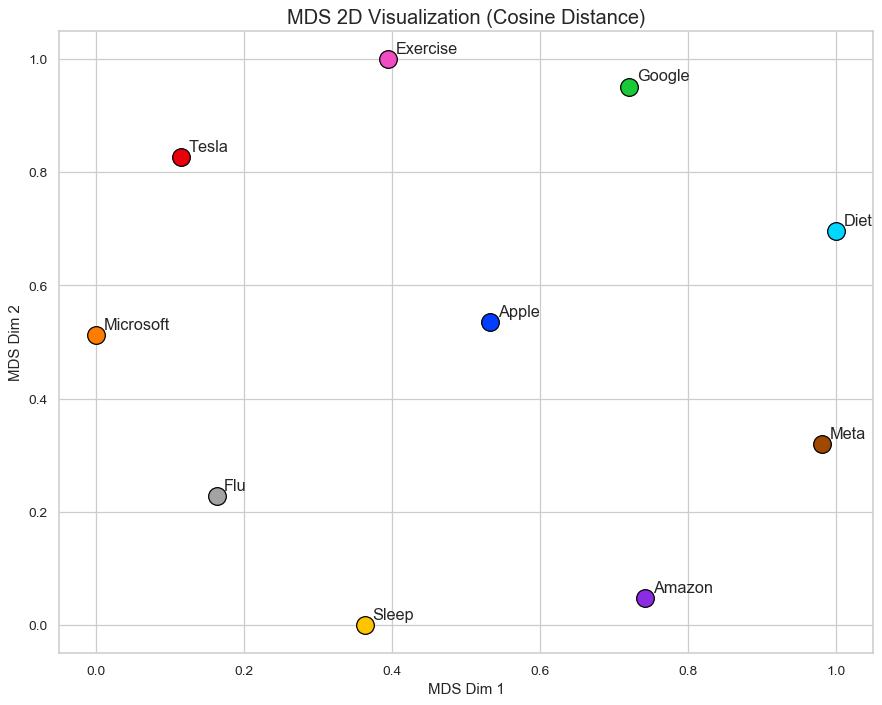

In [6]:
palette = sns.color_palette("bright", len(labels))
plt.figure(figsize=(10, 8))
for i, label in enumerate(labels):
    plt.scatter(coords_cosine_norm[i, 0], coords_cosine_norm[i, 1],
                color=palette[i], s=200, edgecolors='black')
    plt.text(coords_cosine_norm[i, 0]+0.01, coords_cosine_norm[i, 1]+0.01,
             label, fontsize=13)
plt.title("MDS 2D Visualization (Cosine Distance)", fontsize=16)
plt.xlabel("MDS Dim 1")
plt.ylabel("MDS Dim 2")
plt.grid(True)
plt.tight_layout()
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_010.png)

初步观察，科技类文本互相靠近，健康类文本聚在一起，商业内容（如 Meta, Amazon) 相对孤立，Tesla 介于科技和商业之间。

### 算法优化一：参数调节

经典 MDS 时，参数选择直接影响精度和稳定性。

In [7]:
mds2 = MDS(n_components=2, dissimilarity='precomputed',
           random_state=42, n_init=20, max_iter=1000,
           eps=1e-6, normalized_stress='auto')
coords2 = mds2.fit_transform(dist_cosine)
coords2_norm = MinMaxScaler().fit_transform(coords2)

- increased `n_init`：多次随机重启减少局部最优；
- increased `max_iter`：更多迭代提供更稳定的解；
- eps 更小：提高精度；
- normalized_stress 自动规范 stress 值。

![原文参考图，当前结果见代码输出](attachments/img_011.png)

重新绘图后，我们发现点簇更清晰，整体布局更稳定。

### 算法优化二：距离度量升级

“余弦距离”适用大文本，但存在语义局限。我们用 **LSA（TruncatedSVD） 嵌入 + Euclidean 距离** 尝试改进。

/opt/anaconda3/lib/python3.13/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


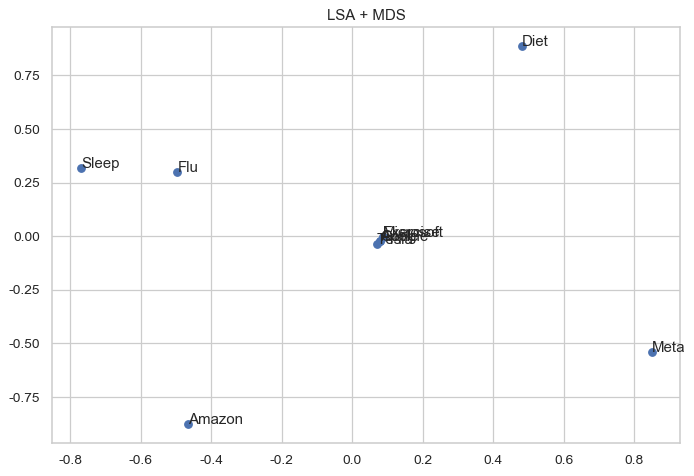

In [8]:
from sklearn.decomposition import TruncatedSVD
# 用潜在语义分析替代 BERT：仍然比较文本表示如何影响 MDS。
lsa = TruncatedSVD(n_components=5, random_state=42)
lsa_emb = lsa.fit_transform(tfidf_matrix)
dist_lsa = pairwise_distances(lsa_emb, metric='euclidean')
mds_lsa = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
coords_lsa = mds_lsa.fit_transform(dist_lsa)
plt.figure(figsize=(9, 6))
plt.scatter(coords_lsa[:, 0], coords_lsa[:, 1])
for label, point in zip(labels, coords_lsa):
    plt.annotate(label, point)
plt.title('LSA + MDS'); plt.show()

LSA（TruncatedSVD） 嵌入捕捉深层上下文，比简单词袋模型表现更语义一致。

可视化绘制及对比后，会发现 LSA（TruncatedSVD） 降维结果中，同一类标签聚合效果更明显，类间界限更清晰。

### 算法优化三：替代降维算法对比

比较 MDS、t‑SNE、UMAP 三算法在同一输入上的表现：

In [9]:
from sklearn.manifold import TSNE
import umap

# t-SNE
tsne = TSNE(n_components=2, perplexity=3, metric='cosine', random_state=42)
coords_tsne = tsne.fit_transform(tfidf_matrix.toarray())
coords_tsne_norm = MinMaxScaler().fit_transform(coords_tsne)

# UMAP
um = umap.UMAP(n_neighbors=5, metric='cosine', random_state=42)
coords_umap = um.fit_transform(tfidf_matrix.toarray())
coords_umap_norm = MinMaxScaler().fit_transform(coords_umap)

/tmp/ml-notebook-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


将三图并排展示，通过视觉对比分析：

- **t‑SNE**：聚合但不保全全局结构；
- **UMAP**：速度快，保全局拓扑；
- **MDS**：强调保持高维距离，但低维聚类效率略弱。

## 模型分析

### 使用 MDS 的优缺点

**优点**：

1. **保留全局距离结构**：MDS 通过保持原始“距离矩阵”中各个样本之间的相对距离，尽量还原高维空间的全局几何结构。这在需要分析对象间“相似性”或“相对位置”的任务中非常有价值，例如客户画像、文档聚类等。
2. **支持任意距离度量**：不同于 PCA 只能处理欧氏空间，MDS 可以处理任意距离矩阵，如余弦距离、欧氏距离、曼哈顿距离甚至自定义相似性，适配性强，适用于文本、图像等多模态数据。
3. **解释性强、几何直观**：降维后的坐标点是真实距离映射而非概率变换，容易进行“空间解释”与“人为理解”，特别适合需要向非技术人员展示的数据分析工作，如产品数据分析报告、市场研究等。
4. **不依赖线性假设**：相比 PCA，MDS 不要求数据服从线性分布，能在非线性场景中有更自然的降维表达。

**缺点**：

1. **对数据规模敏感，难以扩展**：MDS 在输入是距离矩阵时，计算复杂度为 $O(n^2)$，尤其是经典 MDS 对于上万样本时几乎不可用。此点在大数据场景（如推荐系统）中是严重劣势。
2. **对噪声敏感，鲁棒性差**：因为 MDS 强依赖于初始距离矩阵，一旦距离计算中存在误差或噪声（如文本中某些词频过高但无语义信息），可能导致结果畸形。
3. **局部结构表达不足**：MDS 注重保留全局结构，但可能忽视数据的局部聚类结构，不利于发现小规模簇或细粒度语义。
4. **缺乏可扩展性和交互性**：不支持“增量学习”，即新数据点无法在已有 MDS 空间中被合理投影，需要重新练。

### MDS 与相似降维算法对比

| 特性 / 算法 | MDS（多维尺度分析） | PCA（主成分分析） | t‑SNE（随机邻域嵌入） | UMAP（统一流形近似投影） |
|-|-|-|-|-|
| 保留结构类型 | 全局距离结构 | 全局方差结构（线性） | 局部邻域关系 | 局部 + 全局拓扑 |
| 支持任意距离度量 | 是 | 否（仅欧氏） | 是 | 是 |
| 是否线性方法 | 否 | 是 | 否 | 否 |
| 噪声鲁棒性 | 中等（受距离矩阵影响） | 高 | 中等 | 高 |
| 可视化聚类清晰度 | 一般（结构主导） | 一般（线性结构） | 高 | 高 |
| 算法复杂度 | 高：$O(n^2)$ | 低：$O(n \cdot d^2)$ | 中：随机过程 | 低：近似KNN + 简单优化 |
| 对大数据支持 | 差（不可扩展） | 强 | 差（局部优化） | 好（近似方法） |
| 是否支持增量学习 | 否 | 否 | 否 | 支持 |
| 是否适合文本相似性 | 适合 | 限（需向量化） | 非常适合 | 非常适合 |

### MDS 的适用场景与替代建议

**适合使用 MDS 的情境**：

1. **分析目标是“距离/相似度”的还原或可视化**：比如用户偏好图谱、城市距离、文档相似度可视化等问题，MDS 能给出一个几何上的“还原图”。
2. **数据量不大但希望解释性强**：比如 10\~200 个样本的可视化或语义关系图（如知识图谱、关系网络），MDS 能保留直观空间结构。
3. **自定义距离/相似度计算方式时**：如使用文本嵌入后的曼哈顿距离、图神经网络后的图嵌入相似性等，MDS 是一种通用的可视化工具。

**建议改用其他算法的情境**：

1. **数据样本量 > 2000 或期望运行效率高**  
→ 推荐使用 **UMAP**，可扩展性强且速度快；
2. **强调聚类可视化与类间边界清晰度**  
→ 推荐使用 **t‑SNE** 或 **UMAP**，能更好保持局部簇结构；
3. **需要支持新数据增量添加的系统**  
→ MDS 不支持动态添加新样本，而 **UMAP** 支持投影新数据点；
4. **数据维度极高（如图像、语音、嵌入）且已用深度特征**  
→ 推荐使用 **PCA + t-SNE / UMAP** 联合降维，既快又稳。

## 总结

**MDS 更像是一把测距尺**：当你希望“还原关系”的时候它很有用，但当你希望“发现结构”、“提高聚类清晰度”、“加快运行效率”时，UMAP 和 t‑SNE 会是更好的工具。